# Exercise 1: NumPy Arrays vs PyTorch Tensors — Solution

In this exercise, you will compare the performance of **matrix multiplication** across three backends:
- **NumPy arrays** (CPU only)
- **PyTorch Tensors on CPU**
- **PyTorch Tensors on GPU** (CUDA)

You will learn:
- How to create random matrices with NumPy and PyTorch
- How to move tensors between CPU and GPU using `.to()`
- Why GPU acceleration matters for large-scale linear algebra operations

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

# **2. Benchmarking Function**

The helper function `time_matmul` measures how long it takes to perform **10 matrix multiplications** of a square matrix with itself. It dispatches to either `np.matmul` or `torch.matmul` depending on the input type.

This allows us to fairly compare NumPy vs PyTorch (CPU) vs PyTorch (GPU) under the same workload.

In [2]:
def time_matmul(type,x):
  """Returns the time required to do 10 matrix multiplications
  
  Parameters:
  type (string): The type of input matrix (x): 'Numpy' or Tensor (CPU or GPU)
  x (matrix): A square array to do matrix multiplication

  Returns:
  int: Time required to do 10 matrix multiplications
  """
  
  start = time.time()
  if type=='numpy':
    for loop in range(10):
      np.matmul(x,x)
  else:
    for loop in range(10):
      torch.matmul(x,x)
  return (time.time() - start)

# **3. Run the Benchmark**

For matrix sizes from 500×500 to 3000×3000 (in steps of 500), create random matrices and time the matrix multiplication for each backend.

**Hints:**
- NumPy: `np.random.uniform(size=[shape, shape])` creates a random matrix
- PyTorch CPU: `torch.rand([shape, shape])` creates a random tensor on CPU
- PyTorch GPU: use `.to('cuda:0')` to move a tensor to the GPU

**Question:** Why do we expect GPU tensors to be significantly faster for large matrices?

In [3]:
shape_dim = []
numpy_time = []
cpu_tensor_time = []
gpu_tensor_time = []

for shape in range(500,3001,500):
  shape_dim.append(shape**2)

  # Create a numpy array of size [shape, shape] with elements sampled from 
  # an uniform random ( over interval [0,1) ) distribution
  # Use function 'time_matmul' with type 'numpy' and append resulting time 
  # to 'numpy_time'
  x_np = np.random.uniform(size=[shape,shape])
  numpy_time.append(time_matmul('numpy',x_np))
  
  # Create a Tensor on CPU of size [shape, shape] with elements sampled from 
  # an uniform random ( over interval [0,1) ) distribution
  # Use function 'time_matmul' with type 'cpu' and append resulting time 
  # to 'cpu_tensor_time'
  x = torch.rand([shape, shape]).to('cpu')
  cpu_tensor_time.append(time_matmul('cpu',x))

  # Create a Tensor on GPU of size [shape, shape] with elements sampled from 
  # an uniform random ( over interval [0,1) ) distribution
  # Use function 'time_matmul' with type 'gpu' and append resulting time 
  # to 'gpu_tensor_time'
  x = torch.rand([shape, shape]).to('cuda:0')
  gpu_tensor_time.append(time_matmul('gpu',x))



# **4. Visualize Results**

Plot the computation time as a function of matrix size for all three backends. You should observe that:
- **NumPy** and **CPU Tensors** have similar performance (both run on CPU)
- **GPU Tensors** are dramatically faster for large matrices due to massive parallelism

The GPU advantage grows with matrix size because GPUs have thousands of cores optimized for the parallel arithmetic operations that matrix multiplication requires.

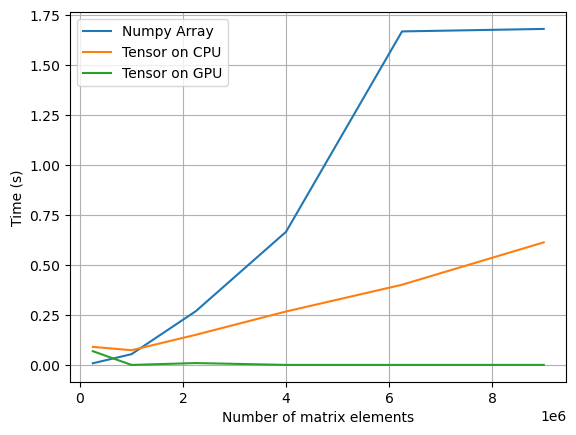

In [4]:
plt.figure()
plt.plot(shape_dim,numpy_time,label="Numpy Array")
plt.plot(shape_dim,cpu_tensor_time,label="Tensor on CPU")
plt.plot(shape_dim,gpu_tensor_time,label="Tensor on GPU")
plt.grid()
plt.xlabel("Number of matrix elements")
plt.ylabel("Time (s)")
plt.legend()
plt.show()